In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

# CSV 파일 불러오기 + 데이터 확인 (컬럼명, 레이블 수)

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/5week/wine.csv")

# 데이터 확인
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [14]:
# 컬럼명 확인
df.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

Text(0.5, 1.0, 'Label')

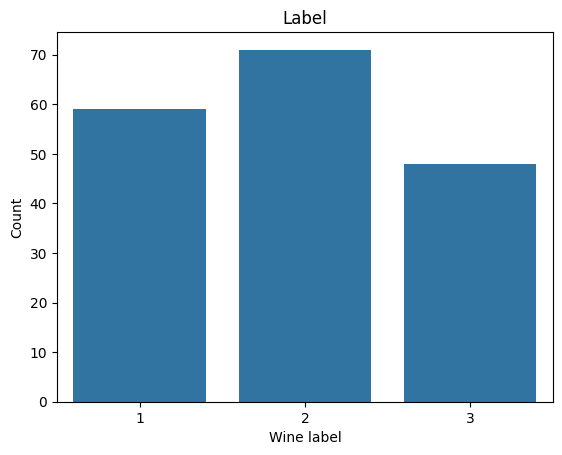

In [36]:
# 레이블 갯수 확인 (그래프)
sns.countplot(data = df, x="Wine")
plt.xlabel("Wine label")
plt.ylabel("Count")
plt.title("Label")

In [16]:
# 레이블 갯수 확인 (숫자)
df['Wine'].value_counts()

,count
Wine,
2,71
1,59
3,48


# 결측치 확인

In [17]:
# 결측치 확인
df.isnull().sum()

,0
Wine,0
Alcohol,0
Malic.acid,0
Ash,0
Acl,0
Mg,0
Phenols,0
Flavanoids,0
Nonflavanoid.phenols,0
Proanth,0


# 데이터 분포 확인 (컬럼별 히스토그램, 산점도)
- 모델 학습 전, 한 컬럼이 어떤 값들이 어떻게 퍼져있는지 보는 것

/tmp/ipykernel_6500/1198221141.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Alcohol'], kde = True, hist = False, ax=ax1)
/tmp/ipykernel_6500/1198221141.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Flavanoids'], ax=ax2)


<Axes: xlabel='Flavanoids', ylabel='Density'>

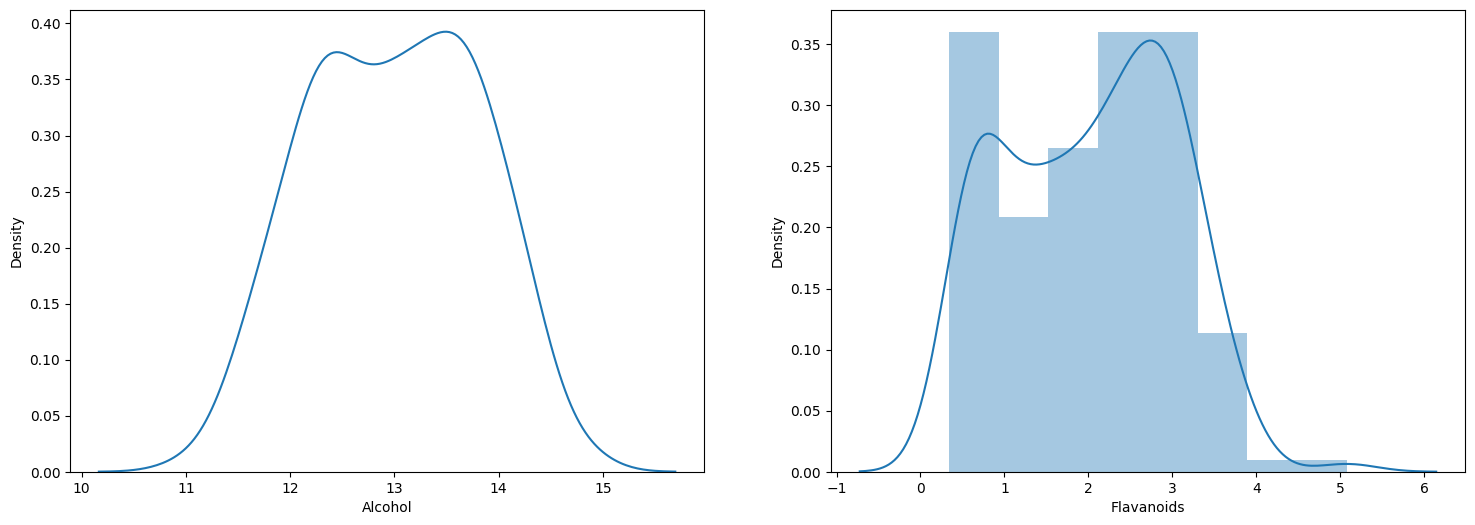

In [18]:
# 컬럼별 히스토그램 확인
# 'Alcohol(알코올도수)'와'Flavanoids(항산화성분량)' 칼럼 선택

figure = plt.figure(figsize=(18,6))

ax1 = plt.subplot(1,2,1)
sns.distplot(df['Alcohol'], kde = True, hist = False, ax=ax1)

ax2 = plt.subplot(1,2,2)
sns.distplot(df['Flavanoids'], ax=ax2)

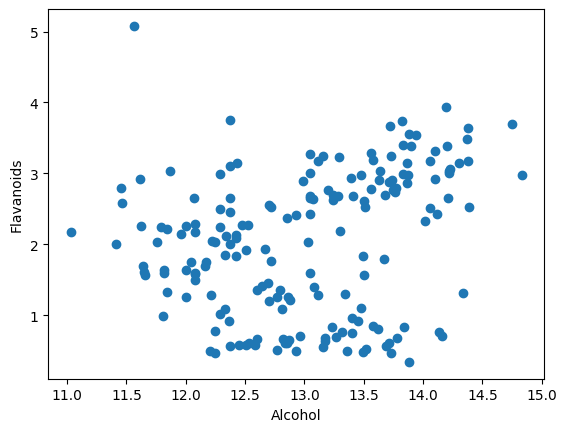

In [19]:
# 산점도 확인

plt.scatter(df['Alcohol'], df['Flavanoids'])
plt.xlabel('Alcohol')
plt.ylabel('Flavanoids')

plt.show()

# X / y 설정

In [20]:
X=df.drop('Wine',axis=1)
X.head()

y=df['Wine']
y.value_counts()

# 데이터의 처음 5개 행 출력 (default = 5)
y.head()

,Wine
0,1
1,1
2,1
3,1
4,1


# 원-핫 인코딩
- 범주형(label)을 모델이 이해할 수 있는 숫자(벡터) 형태로 바꾸는 것
  - why? 모델이 데이터의 순서가 있다고 잘못 해석할 수 있음 > 크기 개념이 없는 독립적인 벡터 형태로 변환
  - when? 분류 문제 + 딥러닝 (특히 Softmax)

In [21]:
# pd.get_dummies(y) : label을 원-핫 형태로 변환
# .values : pandas → numpy 배열로 변환

Y = pd.get_dummies(y).values

# train / test 데이터 분할

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# 정규화 StandardScaler

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP(Dense) 모델 생성
- 입력 데이터의 여러 특성을 받아, 클래스(label)를 분류하는 신경망 모델

In [31]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

# 빈 신경망 모델 생성
model = Sequential()

# 은닉층 생성 : Dense(뉴런수, 입력특성수, 활성화함수)
model.add(Dense(32,input_shape=(13,),activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(3,activation='softmax'))

# 학습 방법 설정 : compile(학습률, 손실함수, 성능확인방법)
model.compile(Adam(learning_rate=0.001),'categorical_crossentropy',metrics=['accuracy'])

# 모델 구조 출력
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,139 (4.45 KB)

 Trainable params: 1,139 (4.45 KB)

 Non-trainable params: 0 (0.00 B)

# 모델 훈련 및 결과 출력
- 학습 데이터를 이용해 신경망을 훈련시키고 > 테스트 데이터에 대한 예측 결과를 만든 뒤 > 그 결과를 최종 클래스 형태로 바꾸는 코드
  - fit() : 모델 학습
  - predict() : 테스트 데이터 예측
  - argmax() : 확률을 클래스 인덱스로 변환

In [32]:
# 모델 학습
# model_history : 학습 과정 중 기록 저장
# fit(x,y, 전체데이터 100번 반복, 한 번에 32개씩 나눠서, 매 epoch마다 테스트셋으로 성능 확인)
# X_train과 y_train을 보고 가중치를 조금씩 수정하면서 정답을 더 잘 맞추도록 학습
model_history=model.fit(x=X_train, y=y_train, epochs=100, batch_size=32,validation_data= (X_test,y_test))

# 테스트 데이터에 대한 예측값 출력
y_pred = model.predict(X_test)

# 실제값(정답)을 클래스 인덱스로 변환
y_test_class = np.argmax(y_test,axis=1)

# 예측 확률을 최종 클래스 인덱스로 변환
y_pred_class = np.argmax(y_pred,axis=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.2535 - loss: 1.1964 - val_accuracy: 0.1667 - val_loss: 1.2309
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2887 - loss: 1.1330 - val_accuracy: 0.3056 - val_loss: 1.1629
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3662 - loss: 1.0754 - val_accuracy: 0.3889 - val_loss: 1.1065
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4296 - loss: 1.0257 - val_accuracy: 0.4167 - val_loss: 1.0562
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5141 - loss: 0.9793 - val_accuracy: 0.5556 - val_loss: 1.0090
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5634 - loss: 0.9363 - val_accuracy: 0.6111 - val_loss: 0.9658
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6197 - loss: 0.8915 - val_accuracy: 0.6111 - val_loss: 0.9250
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6901 - loss: 0.8450 - val_accuracy: 0.6667 - val_loss:

# Loss(손실값) 변화 그래프
- 노란색: 학습데이터 손실 Training loss
- 빨간색: 검증데이터 손실 Validation loss

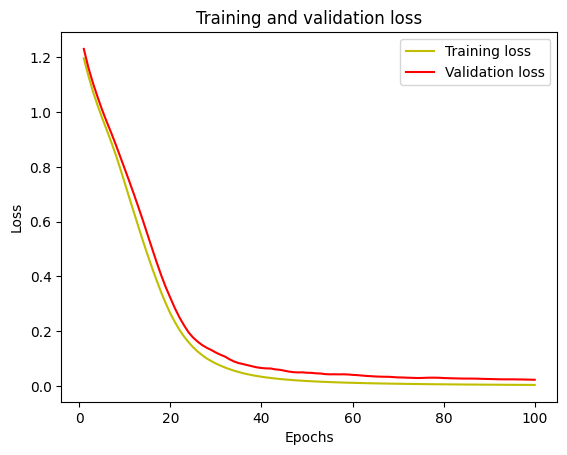

In [33]:
# 학습데이터 손실값 가져오기
loss =model_history.history['loss']
# 검증데이터 손실값 가져오기
val_loss =model_history.history['val_loss']

# epoch 범위 설정 (1~30)
epochs = range(1, len(loss) + 1)

# 그래프 출력
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy(정확도) 변화 그래프
- 노란색: Training accuracy (학습 데이터 정확도)
- 빨간색: Validation accuracy (검증 데이터 정확도)

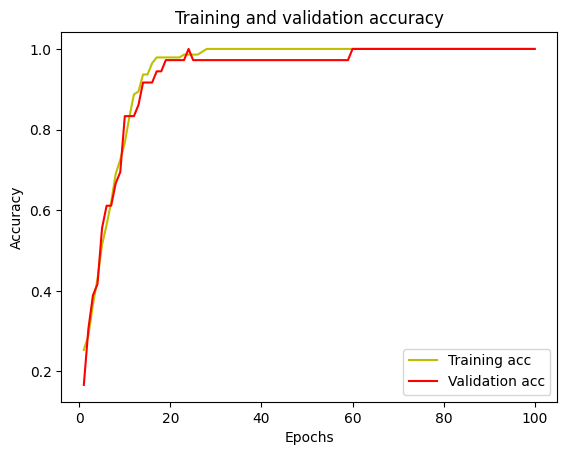

In [34]:
# 학습데이터 정확도
acc =model_history.history['accuracy']
# 검증데이터 정확도
val_acc =model_history.history['val_accuracy']

# 학습데이터 정확도 그래프
plt.plot(epochs, acc, 'y', label='Training acc')
# 검증데이터 정확도 그래프
plt.plot(epochs, val_acc, 'r', label='Validation acc')

# 그래프 그리기
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 모델 성능 평가 Accuracy of the predicted values
- 모델이 얼마나 잘 맞췄는지 구체적으로 분석한 결과
  - precision (정밀도) : 예측값 중 실제 정답은 몇 퍼센트?
  - recall (재현율/민감도) : 실제 정답 중 제대로 예측한 것은 몇 퍼센트?
  - f1 : 균형지표 (precision + recall)
  - accuracy : 최종 정확도

In [35]:
from sklearn.metrics import classification_report,confusion_matrix

# precision, recall, F1-score 출력
print(classification_report(y_test_class,y_pred_class))

# 실제 vs 예측 비교 출력
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00         6

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
